# Projet de machine learning : prédire l'intention de poursuivre des études supérieures

## Objectif global du notebook
Dans ce notebook, l'objectif est de construire un modèle capable de prédire si un élève souhaite **continuer vers l'enseignement supérieur** à partir de ses caractéristiques scolaires, familiales et comportementales.

L'idée n'est pas seulement d'obtenir un bon score de prédiction. Le vrai enjeu est de comprendre **quelles variables expliquent le plus cette intention**, de vérifier qu'il n'y a pas de biais méthodologique comme le **data leakage**, puis de comparer plusieurs approches pour retenir un modèle cohérent et défendable.

Le notebook suit donc une logique simple :
1. charger et rassembler les données ;
2. regarder rapidement leur qualité ;
3. construire la cible et enrichir les variables ;
4. entraîner plusieurs modèles ;
5. comparer une version avec fuite d'information et une version plus propre ;
6. visualiser les performances finales.


In [1]:
import pandas as pd


In [2]:
df_mat = pd.read_csv("../data/raw/student-mat.csv",sep=';')
df_por = pd.read_csv("../data/raw/student-por.csv",sep=';')


## 1. Construction d'une base de travail unique

### Objectif de cette partie
Comme les deux fichiers décrivent le même type de population mais dans deux matières différentes, on choisit ici de les **concaténer verticalement** pour créer une seule base d'analyse.

Cette décision permet :
- d'augmenter le nombre total d'observations ;
- de disposer d'un échantillon plus riche pour l'entraînement des modèles ;
- de limiter le risque d'avoir un dataset trop petit pour la partie machine learning.



In [3]:
df = pd.concat([df_mat, df_por])

df.to_csv('../data/processed/student_data.csv', index=False) #On sauvegarde le nouveau df concatené 

## 2. Qualité du dataset

### Objectif de cette partie
Avant de construire un modèle, il faut vérifier si les données sont **exploitables**. Cette phase sert à repérer les forces et les faiblesses du dataset : taille, valeurs manquantes, cohérence générale et présence éventuelle d'anomalies.

Cela nous permet également de pouvoir mieux guider nos LLM vers un modèle optimal. 


### Taille du jeu de données
la taille est faible ce qui est un point négatif de notre df.


In [4]:
import pandas as pd
rows, cols = df.shape
print(f"Nombre de lignes : {rows}")
print(f"Nombre de colonnes : {cols}")


Nombre de lignes : 1044
Nombre de colonnes : 33


### Vérification des valeurs manquantes
Aucune valeur manquante, c'est un bon point.


In [5]:
miss_col = df.isnull().mean()         
miss_all = df.isnull().values.mean()  
miss_all 
miss_col


school        0.0
sex           0.0
age           0.0
address       0.0
famsize       0.0
Pstatus       0.0
Medu          0.0
Fedu          0.0
Mjob          0.0
Fjob          0.0
reason        0.0
guardian      0.0
traveltime    0.0
studytime     0.0
failures      0.0
schoolsup     0.0
famsup        0.0
paid          0.0
activities    0.0
nursery       0.0
higher        0.0
internet      0.0
romantic      0.0
famrel        0.0
freetime      0.0
goout         0.0
Dalc          0.0
Walc          0.0
health        0.0
absences      0.0
G1            0.0
G2            0.0
G3            0.0
dtype: float64

### Vérification des outliers
Cette partie sert à repérer d'éventuels **outliers** sur les notes finales. Pour avoir une idée s'il y a des abérations sur notre jeu de données. 
Dans notre cas il n'y en a pas beaucoup, ce qui est positif. 


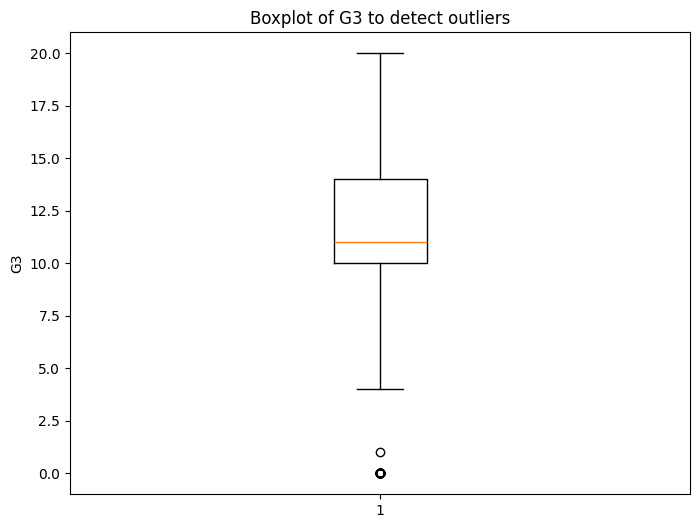

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.boxplot(df['G3'])
plt.title('Boxplot of G3 to detect outliers')
plt.ylabel('G3')
plt.show()


## 3. Mise en place du cadre de modélisation

- séparer les données en apprentissage et test -> pour notre cross-validation de fin;
- encoder et standardiser les variables, car beaucoup de nos données de sont pas numériques ;
- créer des pipelines ;
- évaluer plusieurs modèles ;
- comparer les performances -> choisir le bon modèle en évitant l'overfitting. 

Cette partie pose l'infrastructure complète du workflow de classification.


In [7]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    make_scorer
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC

RANDOM_STATE = 42


## 3.1. Définition de la variable cible et enrichissement des données

### Objectif de cette partie
Le choix de la **target** est central dans le projet. Ici, on retient la variable `higher`, car elle répond directement à la problématique : savoir si l'élève souhaite ou non poursuivre des études supérieures.



In [8]:
TARGET_COL = "higher" 
df["target_risk"] = df[TARGET_COL].map({"yes": 0, "no": 1}).astype("int64") #On encode les données yes et no par 0 et 1 respectivement. 

print("\nTarget distribution (0=no risk / 1=risk):")
print(df["target_risk"].value_counts())
print(df["target_risk"].value_counts(normalize=True))


Target distribution (0=no risk / 1=risk):
target_risk
0    955
1     89
Name: count, dtype: int64
target_risk
0    0.914751
1    0.085249
Name: proportion, dtype: float64


Ensuite, on ne se limite pas aux variables brutes du dataset. On crée aussi plusieurs variables dérivées pour mieux capturer :

-la dynamique académique de l'élève ;
-son niveau d'absentéisme ;
-certains comportements sociaux ;
-le niveau de soutien reçu ;
-le contexte éducatif familial.

Cette étape de feature engineering est très importante : elle permet de transformer des informations dispersées en indicateurs plus parlants pour le modèle.

In [9]:
def safe_div(a, b):
    return np.where(b == 0, 0, a / b)

df_fe = df.copy()

if set(["G1", "G2"]).issubset(df_fe.columns):
    df_fe["grade_avg_12"] = df_fe[["G1", "G2"]].mean(axis=1)
    df_fe["grade_trend_12"] = df_fe["G2"] - df_fe["G1"]
    df_fe["grade_momentum"] = safe_div(df_fe["G2"] - df_fe["G1"], df_fe["G1"] + 1)

if "absences" in df_fe.columns:
    df_fe["high_absence_flag"] = (df_fe["absences"] >= df_fe["absences"].quantile(0.90)).astype(int)

if set(["Dalc", "Walc"]).issubset(df_fe.columns):
    df_fe["alc_index"] = (df_fe["Dalc"] + df_fe["Walc"]) / 2

if set(["goout", "freetime"]).issubset(df_fe.columns):
    df_fe["social_index"] = (df_fe["goout"] + df_fe["freetime"]) / 2

if set(["alc_index", "social_index"]).issubset(df_fe.columns):
    df_fe["risk_behavior_index"] = (df_fe["alc_index"] + df_fe["social_index"]) / 2

bin_cols = ["schoolsup","famsup","paid","activities","nursery","internet","romantic"]
for c in bin_cols:
    if c in df_fe.columns:
        df_fe[c] = df_fe[c].map({"yes": 1, "no": 0})

support_components = [c for c in ["schoolsup","famsup","paid","activities","internet","nursery"] if c in df_fe.columns]
if len(support_components) > 0:
    df_fe["support_index"] = df_fe[support_components].fillna(0).sum(axis=1)

if set(["Medu", "Fedu"]).issubset(df_fe.columns):
    df_fe["parent_edu_avg"] = df_fe[["Medu", "Fedu"]].mean(axis=1)
    df_fe["parent_edu_gap"] = (df_fe["Medu"] - df_fe["Fedu"]).abs()

if "failures" in df_fe.columns:
    df_fe["failure_flag"] = (df_fe["failures"] > 0).astype(int)
    df_fe["high_failure_flag"] = (df_fe["failures"] >= 2).astype(int)

print("\nAfter feature engineering:", df_fe.shape)

FN_COST = 4
FP_COST = 1

def business_cost_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return -(FN_COST * fn + FP_COST * fp)  # higher is better

cost_scorer = make_scorer(business_cost_score, greater_is_better=True)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "business_cost": cost_scorer
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("\n✅ Block 1 ready. Now go to Block 2 to configure DROP_COLS, then run Block 3.")



After feature engineering: (1044, 46)

✅ Block 1 ready. Now go to Block 2 to configure DROP_COLS, then run Block 3.


### Ce qui est fait dans la cellule précédente

- La variable `higher` est encodée en binaire pour créer la cible `target_risk`.
- Une valeur de **1** correspond à un élève considéré comme « à risque », c'est-à-dire qui ne souhaite pas continuer dans le supérieur.
- Des variables composites sont créées pour résumer plusieurs dimensions du profil élève.

#### Logique des nouvelles variables créées
- `grade_avg_12` : niveau scolaire moyen sur les deux premières périodes.
- `grade_trend_12` : évolution des résultats entre les deux périodes.
- `grade_momentum` : version normalisée de cette évolution.
- `high_absence_flag` : signal d'absentéisme élevé.
- `alc_index`, `social_index`, `risk_behavior_index` : indicateurs synthétiques de comportement social et de risque.
- `support_index` : quantité de soutien reçu par l'élève.
- `parent_edu_avg` et `parent_edu_gap` : lecture plus simple du capital éducatif familial.
- `failure_flag` et `high_failure_flag` : trace de l'historique d'échec scolaire.

Le but n'est pas de multiplier artificiellement les colonnes, mais de construire des variables plus proches de la réalité métier que l'on veut étudier.


## 4. Contrôle du data leakage

Avant d'entraîner les modèles, on définit quelles colonnes doivent être exclues du jeu de variables explicatives. Cette étape sert surtout à éviter le **data leakage**, c'est-à-dire le fait de donner au modèle une information trop proche de la réponse qu'il doit prédire.



In [10]:
ALWAYS_DROP = ["higher", "target_risk"]

ID_COLS = [
]

POTENTIAL_LEAKAGE = [
]

MANUAL_DROP = [
    "G3"
]


DROP_COLS = list(dict.fromkeys(ALWAYS_DROP + ID_COLS + POTENTIAL_LEAKAGE + MANUAL_DROP))
print("DROP_COLS =", DROP_COLS)


DROP_COLS = ['higher', 'target_risk', 'G3']


## 5. Construction du pipeline principal et benchmark des modèles

La logique suivie est la suivante :
1. définir `X` et `y` ;
2. préparer automatiquement les variables numériques et catégorielles ;
3. diviser les données entre apprentissage et test ;
4. entraîner plusieurs modèles ;
5. comparer leurs performances avec des métriques classiques et une métrique métier.

La métrique métier donne plus de poids aux **faux négatifs**, car dans ce projet il est plus grave de ne pas détecter un élève à risque que de signaler à tort un élève finalement non à risque.


In [11]:
y = df_fe["target_risk"].astype(int)
X = df_fe.drop(columns=DROP_COLS, errors="ignore")

if "absences" in X.columns:
    cap = X["absences"].quantile(0.99)
    X["absences"] = np.minimum(X["absences"], cap)

print("X shape:", X.shape, "| y mean (risk rate):", y.mean())

numeric_features = X.select_dtypes(include=["int64","float64"]).columns.tolist()
categorical_features = [c for c in X.columns if c not in numeric_features]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ],
    remainder="drop"
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

models = {
    "LogReg": LogisticRegression(max_iter=3000, class_weight="balanced"),
    "DecisionTree": DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced"),
    "AdaBoost": AdaBoostClassifier(random_state=RANDOM_STATE),
    "GradientBoosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "SVM": SVC(probability=True, class_weight="balanced", random_state=RANDOM_STATE),
}

rows = []
for name, model in models.items():
    pipe = Pipeline(steps=[("prep", preprocess), ("model", model)])
    res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    rows.append({
        "model": name,
        "acc_mean": res["test_accuracy"].mean(),
        "prec_mean": res["test_precision"].mean(),
        "recall_mean": res["test_recall"].mean(),
        "f1_mean": res["test_f1"].mean(),
        "auc_mean": res["test_roc_auc"].mean(),
        "business_cost_score_mean": res["test_business_cost"].mean(),
    })

bench = pd.DataFrame(rows).sort_values("business_cost_score_mean", ascending=False)
display(bench)

best_model_name = bench.iloc[0]["model"]
print("\n🏆 MOST PERFORMANT model (by CV business_cost_score_mean):", best_model_name)

CHOSEN_MODEL_NAME = "RandomForest" if "RandomForest" in bench["model"].values else best_model_name
print("✅ CHOSEN model for tuning + final:", CHOSEN_MODEL_NAME)

if CHOSEN_MODEL_NAME == "RandomForest":
    base_pipe = Pipeline(steps=[
        ("prep", preprocess),
        ("model", RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced"))
    ])
    param_grid = {
        "model__n_estimators": [200, 500],
        "model__max_depth": [None, 6, 10],
        "model__min_samples_split": [2, 10],
        "model__min_samples_leaf": [1, 3, 5]
    }
elif CHOSEN_MODEL_NAME == "LogReg":
    base_pipe = Pipeline(steps=[
        ("prep", preprocess),
        ("model", LogisticRegression(max_iter=3000, class_weight="balanced"))
    ])
    param_grid = {
        "model__C": [0.1, 1, 3, 10],
        "model__penalty": ["l2"]
    }
elif CHOSEN_MODEL_NAME == "SVM":
    base_pipe = Pipeline(steps=[
        ("prep", preprocess),
        ("model", SVC(probability=True, class_weight="balanced", random_state=RANDOM_STATE))
    ])
    param_grid = {
        "model__C": [0.5, 1, 3, 10],
        "model__kernel": ["rbf", "linear"],
        "model__gamma": ["scale", "auto"]
    }
elif CHOSEN_MODEL_NAME == "GradientBoosting":
    base_pipe = Pipeline(steps=[
        ("prep", preprocess),
        ("model", GradientBoostingClassifier(random_state=RANDOM_STATE))
    ])
    param_grid = {
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.05, 0.1],
        "model__max_depth": [2, 3]
    }
else:
    base_pipe = Pipeline(steps=[("prep", preprocess), ("model", models[CHOSEN_MODEL_NAME])])
    param_grid = {}  # minimal

if len(param_grid) > 0:
    gs = GridSearchCV(
        base_pipe,
        param_grid=param_grid,
        scoring=cost_scorer,   # optimize business cost
        cv=cv,
        n_jobs=-1,
        verbose=0
    )
    gs.fit(X_train, y_train)
    best_model = gs.best_estimator_
    print("\nBest params:", gs.best_params_)
    print("Best CV business_cost_score:", gs.best_score_)
else:
    best_model = base_pipe.fit(X_train, y_train)
    print("\nNo tuning grid provided; trained chosen model directly.")

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1] if hasattr(best_model, "predict_proba") else None

print("\n===== TEST SET RESULTS =====")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred, zero_division=0))
print("F1       :", f1_score(y_test, y_pred, zero_division=0))
if y_proba is not None:
    print("ROC AUC  :", roc_auc_score(y_test, y_proba))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion matrix:\n", cm)
print("\nClassification report:\n", classification_report(y_test, y_pred, zero_division=0))

tn, fp, fn, tp = cm.ravel()
print(f"Business cost on TEST (FN*{FN_COST} + FP*{FP_COST}) = {FN_COST*fn + FP_COST*fp}")

print("\n🎯 FINAL STATEMENT (put in report/presentation):")
print(f"- Most performant model in CV (cost-sensitive): {best_model_name}")
print(f"- Chosen production model (tuned): {CHOSEN_MODEL_NAME} (optimized for minimizing FN-heavy business cost)")

if CHOSEN_MODEL_NAME == "RandomForest":
    prep = best_model.named_steps["prep"]
    ohe = prep.named_transformers_["cat"]
    cat_names = ohe.get_feature_names_out(categorical_features) if len(categorical_features) else np.array([])
    feat_names = np.concatenate([numeric_features, cat_names])

    rf = best_model.named_steps["model"]
    importances = rf.feature_importances_
    imp = pd.DataFrame({"feature": feat_names, "importance": importances}).sort_values("importance", ascending=False)

    print("\nTop 20 features (importance):")
    display(imp.head(20))


X shape: (1044, 43) | y mean (risk rate): 0.08524904214559387


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,model,acc_mean,prec_mean,recall_mean,f1_mean,auc_mean,business_cost_score_mean
3,AdaBoost,0.919760,0.521212,0.326667,0.395429,0.856509,-42.2
0,LogReg,0.816766,0.276695,0.691429,0.392704,0.832568,-43.8
5,SVM,0.888623,0.362451,0.410476,0.375810,0.856662,-43.8
4,GradientBoosting,0.922156,0.593333,0.255238,0.341716,0.863492,-44.8
2,RandomForest,0.920958,0.800000,0.070476,0.128333,0.882177,-52.8
1,DecisionTree,0.870659,0.218162,0.227619,0.218963,0.579139,-54.6



🏆 MOST PERFORMANT model (by CV business_cost_score_mean): AdaBoost
✅ CHOSEN model for tuning + final: RandomForest

Best params: {'model__max_depth': 10, 'model__min_samples_leaf': 5, 'model__min_samples_split': 2, 'model__n_estimators': 500}
Best CV business_cost_score: -38.2

===== TEST SET RESULTS =====
Accuracy : 0.9186602870813397
Precision: 0.5238095238095238
Recall   : 0.6111111111111112
F1       : 0.5641025641025641
ROC AUC  : 0.928737638161722

Confusion matrix:
 [[181  10]
 [  7  11]]

Classification report:
               precision    recall  f1-score   support

           0       0.96      0.95      0.96       191
           1       0.52      0.61      0.56        18

    accuracy                           0.92       209
   macro avg       0.74      0.78      0.76       209
weighted avg       0.92      0.92      0.92       209

Business cost on TEST (FN*4 + FP*1) = 38

🎯 FINAL STATEMENT (put in report/presentation):
- Most performant model in CV (cost-sensitive): AdaBoost


,feature,importance
22,grade_avg_12,0.098314
20,G1,0.094784
21,G2,0.093513
30,parent_edu_avg,0.061649
4,studytime,0.044425
0,age,0.041079
1,Medu,0.036569
29,support_index,0.033593
24,grade_momentum,0.029094
28,risk_behavior_index,0.026792


### Lecture attendue des résultats du benchmark

À la fin de cette cellule, le notebook produit un tableau de comparaison entre plusieurs modèles. Il faut le lire avec deux niveaux d'analyse :
- les métriques classiques (`accuracy`, `precision`, `recall`, `f1`, `roc_auc`) pour juger la performance statistique ;
- le `business_cost_score` pour juger la pertinence du modèle au regard de l'objectif du projet.

Le modèle « le plus performant » n'est donc pas seulement celui qui a le meilleur score global, mais celui qui équilibre le mieux performance et coût métier, avec nottament l'explicabilité du modèle, et le faite d'éviter les erreurs de type 2.


## 6. Modèle A : version avec fuite d'information

### Objectif de cette partie
Cette première version sert de point de comparaison. On entraîne ici un modèle en gardant pratiquement toutes les variables, y compris certaines qui peuvent être trop proches de la cible (par exemple l'élève à le 3e trimestre).

L'intérêt de cette expérience est méthodologique : elle permet d'observer ce qui se passe quand on laisse au modèle des variables potentiellement « trop faciles ». Cela donne souvent de très bons résultats, mais ces résultats peuvent être moins crédibles dans un cadre réel.


In [12]:
y = df_fe["target_risk"]

X_leak = df_fe.drop(columns=["higher", "target_risk"])

X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X_leak, y, test_size=0.2, random_state=42, stratify=y
)

num_cols = X_leak.select_dtypes(include=["int64","float64"]).columns
cat_cols = [c for c in X_leak.columns if c not in num_cols]

preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

model_leak = Pipeline([
    ("prep", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=500,
        max_depth=6,
        random_state=42,
        class_weight="balanced"
    ))
])

model_leak.fit(X_train_l, y_train_l)

y_pred_l = model_leak.predict(X_test_l)
y_proba_l = model_leak.predict_proba(X_test_l)[:,1]

print("MODEL A — WITH LEAKAGE")
print("Accuracy:", accuracy_score(y_test_l, y_pred_l))
print("Precision:", precision_score(y_test_l, y_pred_l))
print("Recall:", recall_score(y_test_l, y_pred_l))
print("F1:", f1_score(y_test_l, y_pred_l))
print("ROC AUC:", roc_auc_score(y_test_l, y_proba_l))

print(confusion_matrix(y_test_l, y_pred_l))


MODEL A — WITH LEAKAGE
Accuracy: 0.9090909090909091
Precision: 0.48148148148148145
Recall: 0.7222222222222222
F1: 0.5777777777777777
ROC AUC: 0.9011052937754509
[[177  14]
 [  5  13]]


Interprétation modèle A

Ce modèle n'est pas forcément celui qu'il faudra retenir au final. Son rôle principal est de servir de **référence haute** en matière de performance. S'il obtient de meilleurs scores, cela peut venir soit d'une vraie information utile, soit d'une fuite d'information.

C'est précisément pour cela qu'il doit être comparé à un second modèle plus strict.


## 7. Modèle B : version sans fuite d'information

### Objectif de cette partie
Dans cette deuxième version, on retire plusieurs variables jugées trop risquées du point de vue méthodologique. L'objectif est de construire un modèle **plus réaliste**. Car on veut que le modèle soit utilisé pendant l'année en cours et donc avant la fin du 3 trimestre par exemple.

Les variables supprimées sont celles qui peuvent être trop proches de la décision finale ou trop liées à des événements observés tardivement dans le parcours de l'élève.

Si ce modèle conserve de bonnes performances malgré ces suppressions, c'est un résultat très fort : cela signifie que le signal prédictif existe réellement dans les autres variables.


In [13]:
DROP_LEAKAGE = [
    "higher",
    "target_risk",
    "G3",
    "paid",
    "support_index",
    "schoolsup",
    "famsup",
    "studytime"
]

X_clean = df_fe.drop(columns=DROP_LEAKAGE, errors="ignore")

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clean, y, test_size=0.2, random_state=42, stratify=y
)

num_cols = X_clean.select_dtypes(include=["int64","float64"]).columns
cat_cols = [c for c in X_clean.columns if c not in num_cols]

preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

model_clean = Pipeline([
    ("prep", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=500,
        max_depth=6,
        random_state=42,
        class_weight="balanced"
    ))
])

model_clean.fit(X_train_c, y_train_c)

y_pred_c = model_clean.predict(X_test_c)
y_proba_c = model_clean.predict_proba(X_test_c)[:,1]

print("MODEL B — WITHOUT LEAKAGE")
print("Accuracy:", accuracy_score(y_test_c, y_pred_c))
print("Precision:", precision_score(y_test_c, y_pred_c))
print("Recall:", recall_score(y_test_c, y_pred_c))
print("F1:", f1_score(y_test_c, y_pred_c))
print("ROC AUC:", roc_auc_score(y_test_c, y_proba_c))

print(confusion_matrix(y_test_c, y_pred_c))


MODEL B — WITHOUT LEAKAGE
Accuracy: 0.9138755980861244
Precision: 0.5
Recall: 0.7777777777777778
F1: 0.6086956521739131
ROC AUC: 0.89586969168121
[[177  14]
 [  4  14]]


### Pourquoi ce modèle B est particulièrement important

Ce modèle permet de répondre à question : *le modèle fonctionne-t-il encore quand on retire les variables potentiellement problématiques ?*

## 8. Comparaison visuelle des performances via la courbe ROC

### Objectif de cette partie
Cette visualisation permet de comparer directement la capacité des deux modèles à séparer les élèves « à risque » des autres. La courbe ROC met en relation :
- le taux de vrais positifs ;
- le taux de faux positifs.

Plus la courbe est proche du coin supérieur gauche, meilleure est la capacité de discrimination du modèle.



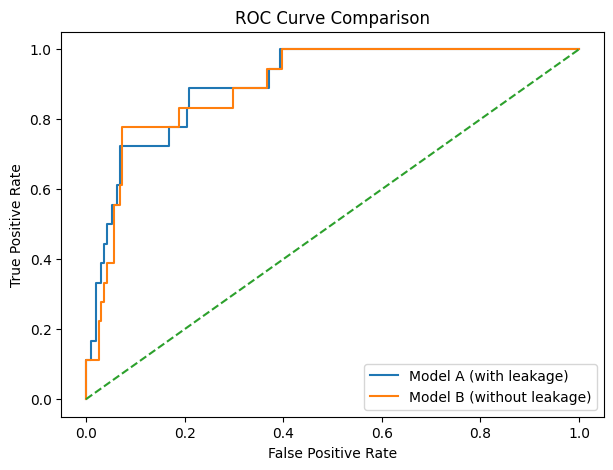

In [14]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr_l, tpr_l, _ = roc_curve(y_test_l, y_proba_l)

fpr_c, tpr_c, _ = roc_curve(y_test_c, y_proba_c)

plt.figure(figsize=(7,5))

plt.plot(fpr_l, tpr_l, label="Model A (with leakage)")
plt.plot(fpr_c, tpr_c, label="Model B (without leakage)")

plt.plot([0,1],[0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()
plt.show()


## 9. Lecture des variables les plus importantes du modèle final

Cette dernière étape sert à interpréter le modèle retenu. L'intérêt n'est plus seulement de savoir **si** le modèle prédit bien, mais surtout de comprendre **sur quoi** il s'appuie.

Cela nous permet de répondre à la question: quelles dimensions du profil élève comptent le plus dans l'intention de poursuivre des études supérieures ?


In [15]:
prep_c = model_clean.named_steps["prep"]
ohe_c = prep_c.named_transformers_["cat"]

cat_names_c = ohe_c.get_feature_names_out(cat_cols) if len(cat_cols) else []
feature_names_c = np.concatenate([num_cols, cat_names_c])

rf_c = model_clean.named_steps["model"]
importances_c = rf_c.feature_importances_

imp_clean = pd.DataFrame({
    "feature": feature_names_c,
    "importance": importances_c
}).sort_values("importance", ascending=False)

imp_clean.head(20)


,feature,importance
18,grade_avg_12,0.114313
17,G2,0.108524
16,G1,0.091697
25,parent_edu_avg,0.067801
0,age,0.050847
1,Medu,0.049312
2,Fedu,0.032447
20,grade_momentum,0.032205
24,risk_behavior_index,0.027731
4,failures,0.025747


### Interprétation du graphique

Le graphique final met en avant les variables qui influencent le plus la prédiction du modèle sans fuite d'information. Il faut ensuite relier ces variables à des interprétations concrètes :
- les performances scolaires précoces ;
- le niveau d'éducation des parents ;
- les antécédents d'échec ;
- certains comportements sociaux.


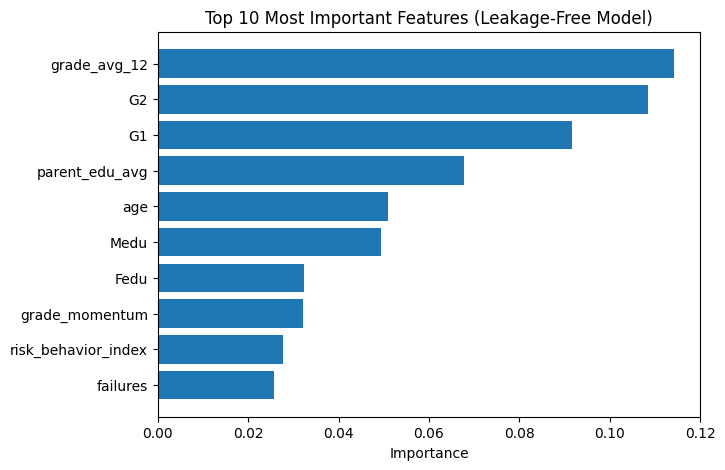

In [16]:
top_clean = imp_clean.head(10)

plt.figure(figsize=(7,5))

plt.barh(top_clean["feature"], top_clean["importance"])
plt.gca().invert_yaxis()

plt.title("Top 10 Most Important Features (Leakage-Free Model)")
plt.xlabel("Importance")

plt.show()


### 10 Test avec un étudiant
On test notre modèle avec un cas réel. 

In [17]:
import joblib

# Assuming 'best_model' is the chosen model from earlier tuning
joblib.dump(best_model, '../models/best_model.pkl')
print("Model saved as '../models/best_model.pkl'")

Model saved as 'best_model.pkl'


In [18]:
import pandas as pd
import joblib

# Load the saved model
best_model = joblib.load('../models/best_model.pkl')

# Create a sample input (example student data)
sample = {
    'age': 18,
    'Medu': 4,
    'Fedu': 4,
    'traveltime': 1,
    'studytime': 2,
    'failures': 0,
    'schoolsup': 0,
    'famsup': 1,
    'paid': 0,
    'activities': 1,
    'nursery': 1,
    'internet': 1,
    'romantic': 0,
    'famrel': 4,
    'freetime': 3,
    'goout': 2,
    'Dalc': 1,
    'Walc': 1,
    'health': 3,
    'absences': 2,
    'G1': 15,
    'G2': 16,
    'grade_avg_12': 15.5,
    'grade_trend_12': 1,
    'grade_momentum': 0.0667,
    'high_absence_flag': 0,
    'alc_index': 1.0,
    'social_index': 2.5,
    'risk_behavior_index': 1.75,
    'support_index': 3,
    'parent_edu_avg': 4.0,
    'parent_edu_gap': 0,
    'failure_flag': 0,
    'high_failure_flag': 0,
    'school': 'GP',
    'sex': 'F',
    'address': 'U',
    'famsize': 'LE3',
    'Pstatus': 'T',
    'Mjob': 'teacher',
    'Fjob': 'health',
    'reason': 'course',
    'guardian': 'mother'
}

# Convert to DataFrame
sample_df = pd.DataFrame([sample])

# Make prediction
prediction = best_model.predict(sample_df)
probabilities = best_model.predict_proba(sample_df)

print("Sample input:")
print(sample_df)
print("\nPrediction (0 = no risk, 1 = risk):", prediction[0])
print("Probability of no risk:", probabilities[0][0])
print("Probability of risk:", probabilities[0][1])

Sample input:
   age  Medu  Fedu  traveltime  studytime  failures  schoolsup  famsup  paid  \
0   18     4     4           1          2         0          0       1     0   

   activities  ...  high_failure_flag  school  sex  address  famsize  Pstatus  \
0           1  ...                  0      GP    F        U      LE3        T   

      Mjob    Fjob  reason  guardian  
0  teacher  health  course    mother  

[1 rows x 43 columns]

Prediction (0 = no risk, 1 = risk): 0
Probability of no risk: 0.9987159663865547
Probability of risk: 0.0012840336134453782
